# 🌲 Random Forest from Scratch (NumPy)

This notebook demonstrates a **Random Forest Classifier built from scratch** using NumPy.

We apply it to the **UCI Heart Disease dataset** to predict whether a patient has heart disease.

---

## 🎯 Objective

Predict:
- **Presence of heart disease** (binary classification)

---

## 📊 Features Used

- Age
- Sex
- Chest pain type
- Resting blood pressure
- Cholesterol
- Fasting blood sugar
- Rest ECG results
- Max heart rate achieved
- Exercise induced angina
- ST depression
- Slope of ST segment
- Number of major vessels
- Thalassemia


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from rice_ml import RandomForestClassifier
from rice_ml import train_test_split, LabelEncoder, accuracy_score, confusion_matrix

## 📥 Load Dataset from UCI

We use the Cleveland Heart Disease dataset from UCI.

In [2]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"

columns = [
    "age", "sex", "cp", "trestbps", "chol", "fbs", "restecg",
    "thalach", "exang", "oldpeak", "slope", "ca", "thal", "target"
]

df = pd.read_csv(url, names=columns)

# Replace missing values
df = df.replace("?", np.nan).dropna()

# Convert to numeric
df = df.astype(float)

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0.0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2.0
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1.0
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0.0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0.0


## 🎯 Target Processing

Convert target into binary classification:

- 0 → No disease  
- 1 → Disease present

In [3]:
df["target"] = (df["target"] > 0).astype(int)

X = df.drop("target", axis=1).values
y = df["target"].values

## 🔀 Train-Test Split

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## 🌲 Train Random Forest

We use:
- 50 trees
- max depth = 5
- sqrt feature sampling

In [5]:
rf = RandomForestClassifier(
    n_trees=50,
    max_depth=5,
    feature_mode="sqrt",
    seed=42
)

rf.fit(X_train, y_train)

## 🔮 Predictions

In [6]:
train_preds = rf.predict(X_train)
test_preds = rf.predict(X_test)

train_acc = accuracy_score(y_train, train_preds)
test_acc = accuracy_score(y_test, test_preds)

print(f"Train Accuracy: {train_acc:.4f}")
print(f"Test Accuracy:  {test_acc:.4f}")

Train Accuracy: 0.8866
Test Accuracy:  0.8136


## 📊 Confusion Matrix

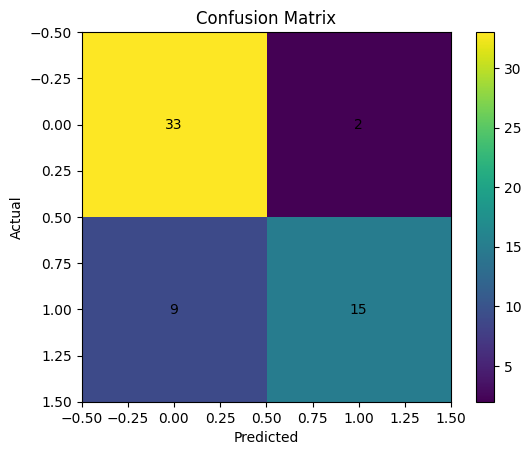

In [8]:
cm = confusion_matrix(y_test, test_preds)

plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()

plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.show()

## 🌲 Feature Importance (Approximation)

We estimate importance by counting how often each feature is used in splits across all trees.

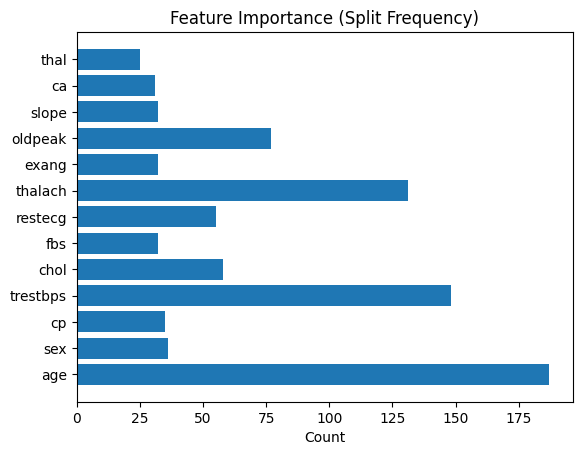

In [9]:
feature_names = df.drop("target", axis=1).columns.tolist()

def count_features(node, counts):
    if not isinstance(node, tuple):
        return
    
    feat, _, left, right = node
    counts[feat] += 1
    
    count_features(left, counts)
    count_features(right, counts)

counts = np.zeros(len(feature_names))

for tree, feats in rf._forest:
    tree_counts = np.zeros(len(feats))
    count_features(tree.root_node, tree_counts)
    
    for i, f in enumerate(feats):
        counts[f] += tree_counts[i]

plt.barh(feature_names, counts)
plt.title("Feature Importance (Split Frequency)")
plt.xlabel("Count")
plt.show()